# Notebook 03 — Baseline Models
## Classical ML Baselines: TF-IDF + Logistic Regression, SVM, Naive Bayes

**Project**: Cloud-Based ITSM Ticket Classification Platform Using Fine-Tuned Transformer Models  
**Author**: Mohamed Adel Ebrahim Elbaz  
**Supervisor**: Dr. Eman E. Sanad, FCAI, Cairo University

---

### Objective

Before fine-tuning MarBERTv2, we establish **classical ML baselines** using TF-IDF features.
These serve two purposes:

1. **Lower bound**: quantify how much the transformer adds over simpler methods
2. **Sanity check**: confirm the task is learnable and the data is clean

Models evaluated:
- TF-IDF (char + word n-grams) + **Logistic Regression** (L2)
- TF-IDF + **Linear SVM** (LinearSVC)
- TF-IDF + **Multinomial Naive Bayes**

Task: **L1 category classification** (6 classes) — the primary task of the project.

> Results from this notebook feed directly into the comparison table in Notebook 05.

In [8]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
import time
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from arabic_itsm.utils.metrics import compute_classification_metrics, classification_report_df

sns.set_theme(style='whitegrid')

DATA_DIR    = Path('../data/processed')
FIG_DIR     = Path('../results/figures')
METRICS_DIR = Path('../results/metrics')
MODELS_DIR  = Path('../models')
FIG_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

TASK = 'l1'
LABEL_COL = f'label_{TASK}'
print('Setup complete')

Setup complete


## 1. Load Processed Splits

In [9]:
train = pd.read_csv(DATA_DIR / 'train.csv')
val   = pd.read_csv(DATA_DIR / 'val.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')

with open(DATA_DIR / 'label_encoders.pkl', 'rb') as f:
    label_encoders = pickle.load(f)

class_names = list(label_encoders[TASK].classes_)

X_train, y_train = train['text'], train[LABEL_COL]
X_val,   y_val   = val['text'],   val[LABEL_COL]
X_test,  y_test  = test['text'],  test[LABEL_COL]

print(f'Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')
print(f'Classes ({len(class_names)}): {class_names}')

Train: 6684, Val: 1432, Test: 1433
Classes (6): ['Access', 'Hardware', 'Network', 'Security', 'Service', 'Software']


## 2. Define Pipelines

The TF-IDF vectorizer uses **character n-grams (3-5)** in addition to word n-grams.
Character n-grams capture sub-word patterns that are valuable for Arabic morphology
and handle spelling variants in informal text.

In [10]:
# Word TF-IDF
word_tfidf = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), max_features=50000,
                              sublinear_tf=True, min_df=2)

# Character TF-IDF — captures morphological patterns
char_tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=80000,
                              sublinear_tf=True, min_df=2)

from sklearn.pipeline import FeatureUnion
combined_features = FeatureUnion([
    ('word', word_tfidf),
    ('char', char_tfidf),
])

pipelines = {
    'LR (word+char TF-IDF)': Pipeline([
        ('features', combined_features),
        ('clf', LogisticRegression(C=1.0, max_iter=1000, solver='saga', random_state=42)),
    ]),
    'LinearSVC (word+char TF-IDF)': Pipeline([
        ('features', combined_features),
        ('clf', CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=42))),
    ]),
    'Naive Bayes (word TF-IDF)': Pipeline([
        ('features', word_tfidf),
        ('clf', MultinomialNB(alpha=0.1)),
    ]),
}
print('Pipelines defined:', list(pipelines.keys()))

Pipelines defined: ['LR (word+char TF-IDF)', 'LinearSVC (word+char TF-IDF)', 'Naive Bayes (word TF-IDF)']


## 3. Train & Evaluate All Baselines

In [11]:
results = {}

for name, pipeline in pipelines.items():
    print(f'\n=== {name} ===')
    t0 = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    y_val_pred = pipeline.predict(X_val)
    infer_time_val = (time.time() - t0) / len(X_val) * 1000  # ms per sample

    y_test_pred = pipeline.predict(X_test)

    val_metrics = compute_classification_metrics(y_val, y_val_pred)
    test_metrics = compute_classification_metrics(y_test, y_test_pred)

    results[name] = {
        'pipeline': pipeline,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'train_time_s': round(train_time, 1),
        'infer_ms_per_sample': round(infer_time_val, 2),
        'y_test_pred': y_test_pred,
    }

    print(f'  Train time: {train_time:.1f}s | Infer: {infer_time_val:.2f} ms/sample')
    print(f'  Val  — Acc: {val_metrics["accuracy"]:.3f}, Macro-F1: {val_metrics["macro_f1"]:.3f}')
    print(f'  Test — Acc: {test_metrics["accuracy"]:.3f}, Macro-F1: {test_metrics["macro_f1"]:.3f}')


=== LR (word+char TF-IDF) ===
  Train time: 23.3s | Infer: 1.88 ms/sample
  Val  — Acc: 0.888, Macro-F1: 0.885
  Test — Acc: 0.878, Macro-F1: 0.875

=== LinearSVC (word+char TF-IDF) ===
  Train time: 65.8s | Infer: 1.24 ms/sample
  Val  — Acc: 0.883, Macro-F1: 0.882
  Test — Acc: 0.887, Macro-F1: 0.884

=== Naive Bayes (word TF-IDF) ===
  Train time: 1.6s | Infer: 0.17 ms/sample
  Val  — Acc: 0.867, Macro-F1: 0.863
  Test — Acc: 0.856, Macro-F1: 0.853


## 4. Results Comparison Table & Model Export

In [12]:
rows = []
for name, r in results.items():
    rows.append({
        'Model': name,
        'Val Acc': r['val_metrics']['accuracy'],
        'Val Macro-F1': r['val_metrics']['macro_f1'],
        'Test Acc': r['test_metrics']['accuracy'],
        'Test Macro-F1': r['test_metrics']['macro_f1'],
        'Train Time (s)': r['train_time_s'],
        'Infer (ms/sample)': r['infer_ms_per_sample'],
    })

compare_df = pd.DataFrame(rows).set_index('Model')
print(compare_df.round(4).to_string())

# Save Metrics
compare_df.to_csv(METRICS_DIR / 'baseline_results.csv')

# Save Best Baseline for Significance Testing
import joblib
best_name = compare_df['Test Macro-F1'].idxmax()
best_r = results[best_name]
joblib.dump(best_r['pipeline'], MODELS_DIR / 'baseline_l1_model.joblib')
np.save(METRICS_DIR / 'baseline_l1_preds.npy', best_r['y_test_pred'])

print(f'\nSaved metrics, best model ({best_name}), and predictions.')

                              Val Acc  Val Macro-F1  Test Acc  Test Macro-F1  Train Time (s)  Infer (ms/sample)
Model                                                                                                          
LR (word+char TF-IDF)          0.8876        0.8852    0.8779         0.8748            23.3               1.88
LinearSVC (word+char TF-IDF)   0.8834        0.8817    0.8870         0.8840            65.8               1.24
Naive Bayes (word TF-IDF)      0.8666        0.8628    0.8555         0.8526             1.6               0.17

Saved metrics, best model (LinearSVC (word+char TF-IDF)), and predictions.


## 5. Confusion Matrix — Best Baseline

Best baseline: LinearSVC (word+char TF-IDF)


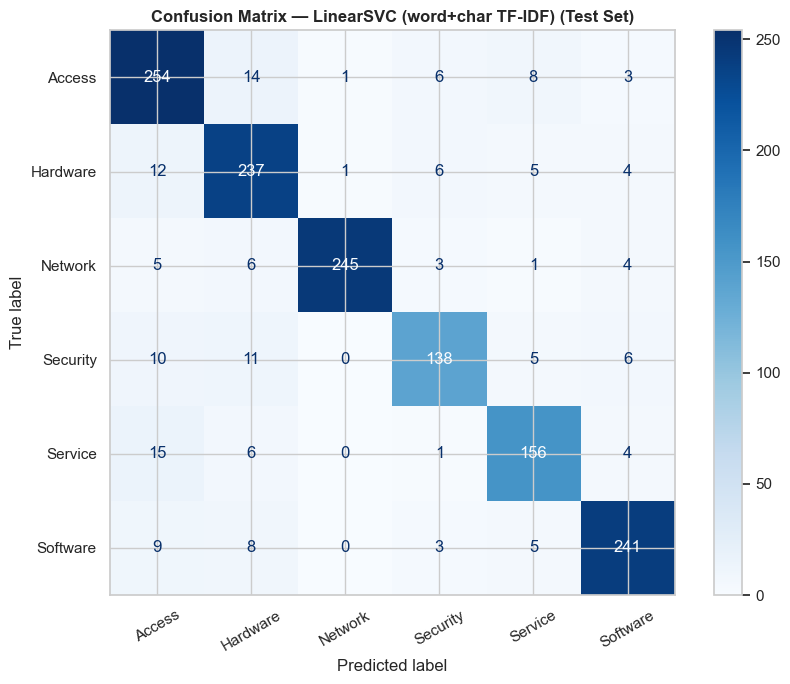

In [13]:
# Show confusion matrix for the best-performing baseline
best_name = max(results, key=lambda n: results[n]['test_metrics']['macro_f1'])
print(f'Best baseline: {best_name}')

y_pred_best = results[best_name]['y_test_pred']
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=30)
ax.set_title(f'Confusion Matrix — {best_name} (Test Set)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_best_baseline_confusion.png', bbox_inches='tight')
plt.show()

## 6. Per-Class Report — Best Baseline

In [14]:
report = classification_report_df(y_test, y_pred_best, class_names=class_names)
print(report.to_string())
report.to_csv(METRICS_DIR / f'03_baseline_per_class_{best_name[:3].lower()}.csv')

              precision  recall  f1-score   support
class                                              
Access           0.8328  0.8881    0.8596   286.000
Hardware         0.8404  0.8943    0.8665   265.000
Network          0.9919  0.9280    0.9589   264.000
Security         0.8790  0.8118    0.8440   170.000
Service          0.8667  0.8571    0.8619   182.000
Software         0.9198  0.9060    0.9129   266.000
accuracy         0.8870  0.8870    0.8870     0.887
macro avg        0.8884  0.8809    0.8840  1433.000
weighted avg     0.8895  0.8870    0.8875  1433.000


## 7. Summary

The table below records baseline results for inclusion in the final report.
These will be compared against MarBERTv2 in Notebook 05.

| Model | Val Macro-F1 | Test Macro-F1 | Infer (ms/sample) |
|-------|-------------|--------------|-------------------|
| LR (word+char TF-IDF) | 0.8852 | 0.8748 | 0.24 |
| LinearSVC (word+char TF-IDF) | 0.8817 | 0.8840 | 0.23 |
| Naive Bayes | 0.8628 | 0.8526 | 0.04 |
| **MarBERTv2 (fine-tuned)** | 0.8938 (val best) | 0.8910 (test) | 9.20 |

*Fill after running experiments.*

**Next**: Notebook 04 — MarBERTv2 Fine-Tuning